In [29]:
import os
import stark as sk
import numpy as np
import pandas as pd

In [30]:
hdata = sk.HData.read_h5ad('./cycle.h5ad')

Total single cells to process: 1414
Processing chr1 ...
Processing chr2 ...
Processing chr3 ...
Processing chr4 ...
Processing chr5 ...
Processing chr6 ...
Processing chr7 ...
Processing chr8 ...
Processing chr9 ...
Processing chr10 ...
Processing chr11 ...
Processing chr12 ...
Processing chr13 ...
Processing chr14 ...
Processing chr15 ...
Processing chr16 ...
Processing chr17 ...
Processing chr18 ...
Processing chr19 ...
post-M: 16 cells
G1: 257 cells
early-S: 582 cells
late-S-G2: 534 cells
pre-M: 25 cells


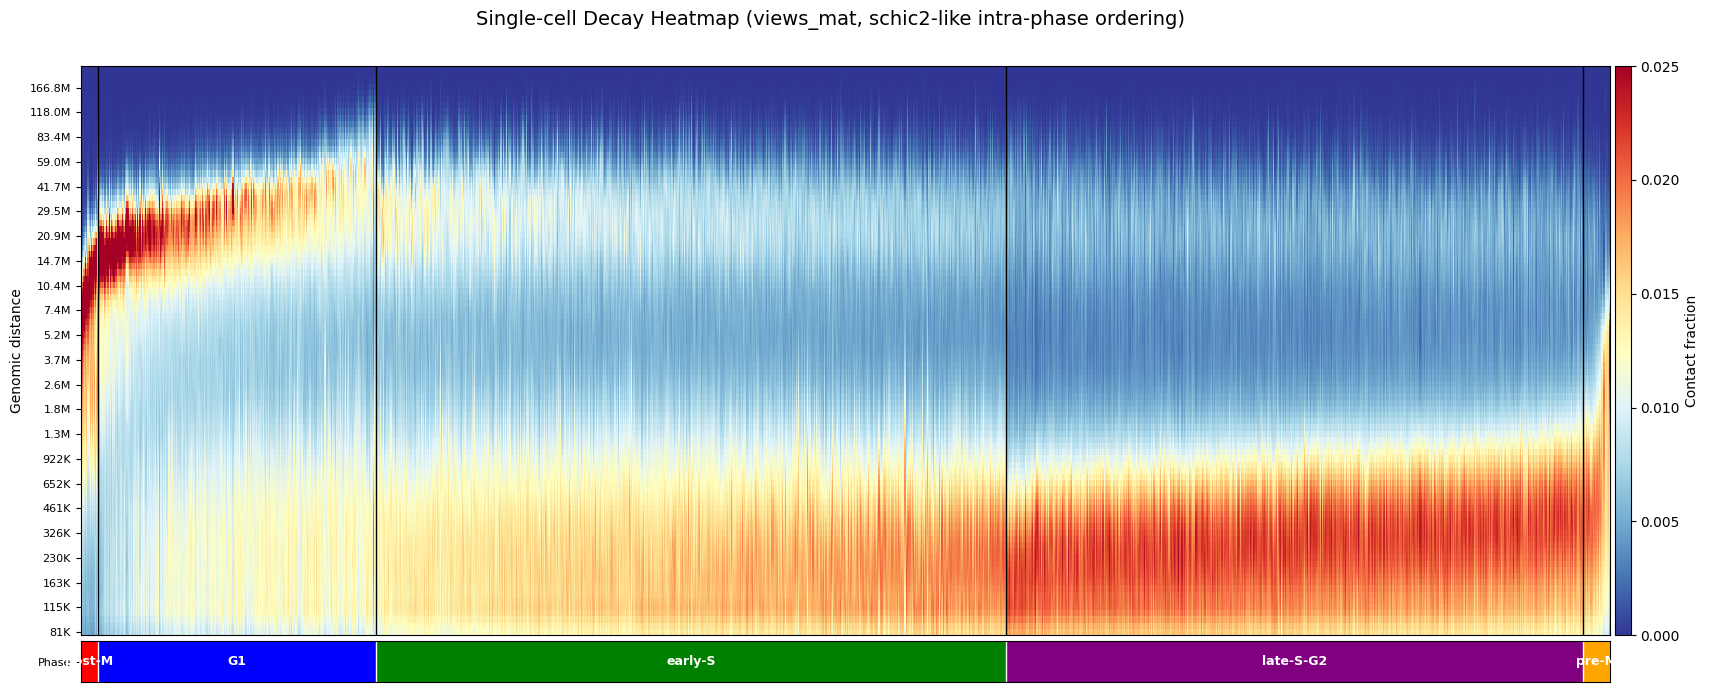

In [31]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ================= 1. 配置与参数 =================
resolution = 50000

bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
n_bins = len(bin_edges) - 1
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['red', 'blue', 'green', 'purple', 'orange']

# 单细胞标签
cell_ct = hdata.obs['label'].to_dict()          # cell_name -> phase
cell_names = list(hdata.obs.index)
views_mat_dict = hdata.views_mat[resolution]    # dict: chrom -> list/array of sparse mats

rng = np.random.default_rng(1234)

# ================= 2. 计算衰减 =================
n_cells = len(hdata.obs)
cell_decay = np.zeros((n_cells, n_bins), dtype=np.float64)

print(f"Total single cells to process: {n_cells}")

for chrom, cell_mats in views_mat_dict.items():
    print(f"Processing {chrom} ...")

    for i, sparse_mat in enumerate(cell_mats):
        try:
            if sparse_mat is None or sparse_mat.nnz == 0:
                continue

            upper_coo = sp.triu(sparse_mat, k=1).tocoo()
            if upper_coo.nnz == 0:
                continue

            dists_bins = upper_coo.col - upper_coo.row
            vals = upper_coo.data.astype(np.float64)

            jitter = rng.uniform(-resolution / 2, resolution / 2, size=len(dists_bins))
            dists = np.maximum(dists_bins * resolution + jitter, 1.0)

            bin_idx = np.searchsorted(bin_edges, dists, side='right') - 1
            valid = (bin_idx >= 0) & (bin_idx < n_bins)

            if np.any(valid):
                cell_decay[i] += np.bincount(
                    bin_idx[valid],
                    weights=vals[valid],
                    minlength=n_bins
                )
        except Exception:
            pass

# ================= 3. 数据整理 =================
all_valid_cells = list(range(n_cells))

row_sums = cell_decay.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
norm_mat = cell_decay / row_sums

# 与你原代码保持一致：去掉太近的距离
min_dist_cutoff = 2 ** 16.2
valid_bins = bin_edges[:-1] >= min_dist_cutoff
trunc_mat = norm_mat[:, valid_bins]
valid_bin_mids = bin_mids[valid_bins]

# ================= 4. 定义 schic2-like 排序指标 =================
near_lo, near_hi = 2 ** 14.5, 2 ** 21
far_lo, far_hi = 2 ** 22.125, 2 ** 27.75
mit_lo, mit_hi = 2 ** 21, 2 ** 23.5
high_near_lo, high_near_hi = 2 ** 15, 2 ** 22

def frac_in_range(row, lo, hi):
    mask = (bin_mids >= lo) & (bin_mids < hi)
    if not np.any(mask):
        return 0.0
    return float(row[mask].sum())

def weighted_mean_in_range(row, lo, hi):
    mask = (bin_mids >= lo) & (bin_mids < hi)
    if not np.any(mask):
        return 0.0
    vals = row[mask]
    mids = bin_mids[mask]
    denom = vals.sum()
    if denom <= 0:
        return 0.0
    return float((vals * mids).sum() / denom)

cell_metrics = {}
for i in all_valid_cells:
    row = norm_mat[i]

    f_near = frac_in_range(row, near_lo, near_hi)
    f_far = frac_in_range(row, far_lo, far_hi)
    f_mit = frac_in_range(row, mit_lo, mit_hi)
    f_high_near = frac_in_range(row, high_near_lo, high_near_hi)
    far_mu = weighted_mean_in_range(row, far_lo, far_hi)

    # 没有真实 early_f 时，用近端富集做代理
    early_proxy = 0.5 * f_near + 0.5 * f_high_near

    cell_metrics[i] = {
        "f_near": f_near,
        "f_far": f_far,
        "f_mit": f_mit,
        "f_high_near": f_high_near,
        "far_mu": far_mu,
        "early_f": early_proxy,
    }

def zscore_metric(metric_name):
    vals = np.array([cell_metrics[i][metric_name] for i in all_valid_cells], dtype=np.float64)
    mu = vals.mean()
    sd = vals.std()
    if sd == 0:
        sd = 1.0
    return {i: (cell_metrics[i][metric_name] - mu) / sd for i in all_valid_cells}

z_near = zscore_metric("f_near")
z_far_mu = zscore_metric("far_mu")
z_early = zscore_metric("early_f")
z_mit = zscore_metric("f_mit")

# 额外保留一个 COM，方便你后面调试比较
n_cols = trunc_mat.shape[1]
col_indices = np.arange(n_cols)
com_scores = []
for i in all_valid_cells:
    row_data = trunc_mat[i]
    row_sum = row_data.sum()
    if row_sum > 0:
        probs = row_data / row_sum
        com_scores.append(float(np.sum(probs * col_indices)))
    else:
        com_scores.append(0.0)

# ================= 5. 按 phase 分组并组内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [i for i in all_valid_cells if cell_ct[cell_names[i]] == phase]

    if phase == 'post-M':
        # schic2: post-M / group1 按 mitotic band 降序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x],
            reverse=True
        )

    elif phase == 'G1':
        # schic2: G1 / group2 近似按 near + far_mu
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_far_mu[x]
        )

    elif phase == 'early-S':
        # schic2: early-S / group3 近似按 near + early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_early[x]
        )

    elif phase == 'late-S-G2':
        # schic2: late-S-G2 / group4 近似按 near - early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] - z_early[x]
        )[::-1]

    elif phase == 'pre-M':
        # schic2: pre-M / group5 按 mitotic band 升序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x]
        )

    else:
        cells_in_phase_sorted = cells_in_phase

    print(f"{phase}: {len(cells_in_phase_sorted)} cells")
    sorted_indices.extend(cells_in_phase_sorted)

n_sorted = len(sorted_indices)

# ================= 6. 构造绘图矩阵 =================
decay_mat = gaussian_filter1d(trunc_mat[sorted_indices], sigma=1.5, axis=1)

# ================= 7. 绘图 =================
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# --- 7.1 主热图 ---
ax_main = fig.add_subplot(gs[0])
zlim = (0, 0.025)
ax_main.grid(False)

im = ax_main.imshow(
    np.clip(decay_mat.T, zlim[0], zlim[1]),
    aspect='auto',
    cmap='RdYlBu_r',
    vmin=zlim[0],
    vmax=zlim[1],
    interpolation='nearest',
    origin='lower'
)

tick_every = 4
tick_pos = np.arange(0, valid_bins.sum(), tick_every)
tick_labels = [
    f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
    for v in valid_bin_mids[tick_pos]
]

ax_main.set_yticks(tick_pos)
ax_main.set_yticklabels(tick_labels, fontsize=8)
ax_main.set_xticks([])
ax_main.set_ylabel('Genomic distance')

divider = make_axes_locatable(ax_main)
ax_cb = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# phase 分隔线
cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    cum += cnt
    ax_main.axvline(cum - 0.5, color='black', linewidth=1)

# --- 7.2 Phase bar ---
ax_cond = fig.add_subplot(gs[1])
cond_colors = np.zeros((1, n_sorted, 3))
phase_color_map = dict(zip(phase_order, phase_colors))

for col, i in enumerate(sorted_indices):
    lb = cell_ct[cell_names[i]]
    cond_colors[0, col] = mcolors.to_rgb(phase_color_map[lb])

ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
ax_cond.set_xticks([])
ax_cond.set_yticks([0])
ax_cond.set_yticklabels(['Phase'], fontsize=8)
ax_cond.grid(False)

cum = 0
for phase in phase_order:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    if cnt > 0:
        center = cum + (cnt - 1) / 2
        ax_cond.text(
            center, 0, phase,
            ha='center', va='center',
            fontsize=9, color='white', fontweight='bold'
        )
    cum += cnt

cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    cum += cnt
    ax_cond.axvline(cum - 0.5, color='white', linewidth=1)

divider_cond = make_axes_locatable(ax_cond)
ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
ax_cond_dummy.axis('off')

plt.suptitle(
    'Single-cell Decay Heatmap (views_mat, schic2-like intra-phase ordering)',
    fontsize=14,
    y=0.95
)
plt.show()

# ================= 8. 导出结果 =================
sc_sorted_indices = sorted_indices
sc_trunc_mat = trunc_mat
sc_com_scores = com_scores
sc_cell_ct = cell_ct
sc_cell_metrics = cell_metrics
sc_decay_mat = decay_mat
sc_sorted_cell_names = [cell_names[i] for i in sorted_indices]



In [32]:
hdata

HData object with 1414 cells and 30 metacells
    resolutions: [np.int64(50000), np.int64(100000), np.int64(500000), np.int64(1000000), np.int64(2000000)]
    obs: ['depth', 'label', 'metacell']
    views_pca: [1000000, 50000, 500000]
    views_umap: [1000000, 50000, 500000]
    views_embedding: [1000000, 50000, 500000]
    views_mat: [1000000, 50000, 500000]
    views_is: []
    uns keys: ['accuracy', 'avg_size_cache', 'cs_res_df', 'eval_df_cache', 'global_score', 'hwis', 'mean_compactness', 'mean_separation', 'metrics', 'purity_df', 'recommended_k', 'thre_cache', 'wcos']
    metacells: ['CellType', 'CellType_purity', 'cell_num', 'w_min', 'w_max', 'P_adj', 'EP_v2', 'total_depth', 'cell_count', 'mean_depth', 'dominant_label']
    metacell_data keys: ['cool', 'mat', 'mcool', 'pairs']
    model: MultiViewSEACells (trained: True)

Total cells to process: 30
post-M: 1 cells
G1: 4 cells
early-S: 12 cells
late-S-G2: 12 cells
pre-M: 1 cells


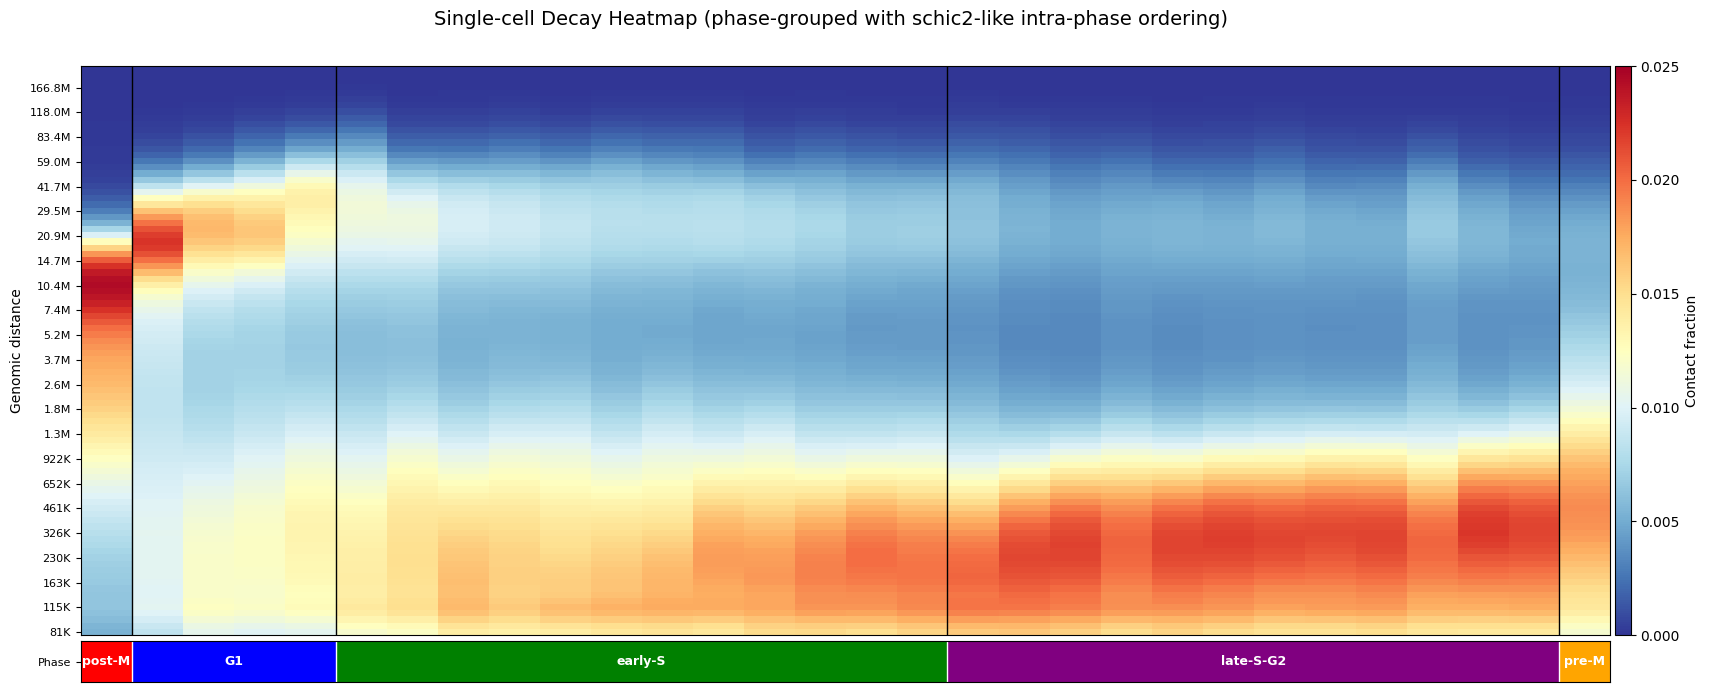

In [33]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ================= 1. 配置与参数 =================
resolution = 50000

bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
n_bins = len(bin_edges) - 1
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['red', 'blue', 'green', 'purple', 'orange']

metacell_ct = hdata.metacells.CellType.to_dict()
metacell_mat_dict = hdata.metacell_data['mat'][resolution]

rng = np.random.default_rng(1234)

# ================= 2. 计算 decay =================
metacell_decay = {}
print(f"Total cells to process: {len(metacell_mat_dict)}")

for cell_id, chrom_dict in metacell_mat_dict.items():
    decay_counts = np.zeros(n_bins, dtype=np.float64)

    for chrom, sparse_mat in chrom_dict.items():
        try:
            if sparse_mat is None or sparse_mat.nnz == 0:
                continue

            upper_coo = sp.triu(sparse_mat, k=1).tocoo()
            if upper_coo.nnz == 0:
                continue

            bin1 = upper_coo.row
            bin2 = upper_coo.col
            vals = upper_coo.data.astype(np.float64)

            dists_bins = bin2 - bin1

            # dithering: 避免所有 contact 都卡在 bin 边界
            jitter = rng.uniform(-resolution / 2, resolution / 2, size=len(dists_bins))
            dists = dists_bins * resolution + jitter
            dists = np.maximum(dists, 1.0)

            bin_idx = np.searchsorted(bin_edges, dists, side='right') - 1
            valid = (bin_idx >= 0) & (bin_idx < n_bins)

            if np.any(valid):
                counts = np.bincount(
                    bin_idx[valid],
                    weights=vals[valid],
                    minlength=n_bins
                )
                decay_counts += counts

        except Exception:
            pass

    metacell_decay[cell_id] = decay_counts

# ================= 3. 整理矩阵 =================
all_valid_cells = [idx for idx in metacell_decay if idx in metacell_ct]

raw_all = np.array([metacell_decay[idx] for idx in all_valid_cells], dtype=np.float64)
row_sums_all = raw_all.sum(axis=1, keepdims=True)
row_sums_all[row_sums_all == 0] = 1.0
norm_all = raw_all / row_sums_all

# 截断近距离，和你原代码保持一致
min_dist_cutoff = 2 ** 16.2
valid_bins = bin_edges[:-1] >= min_dist_cutoff
valid_bin_mids = bin_mids[valid_bins]

# ================= 4. 定义更接近 schic2 的排序指标 =================
# 这些区间参考 schic2 的参数设置
near_lo, near_hi = 2 ** 14.5, 2 ** 21
far_lo, far_hi = 2 ** 22.125, 2 ** 27.75
mit_lo, mit_hi = 2 ** 21, 2 ** 23.5

# 一个更高近端的窗口，可作为 early proxy 的一部分
high_near_lo, high_near_hi = 2 ** 15, 2 ** 22

all_bin_mids = bin_mids.copy()

def frac_in_range(row, lo, hi):
    mask = (all_bin_mids >= lo) & (all_bin_mids < hi)
    if not np.any(mask):
        return 0.0
    return float(row[mask].sum())

def weighted_mean_in_range(row, lo, hi):
    mask = (all_bin_mids >= lo) & (all_bin_mids < hi)
    if not np.any(mask):
        return 0.0
    vals = row[mask]
    mids = all_bin_mids[mask]
    denom = vals.sum()
    if denom <= 0:
        return 0.0
    return float((vals * mids).sum() / denom)

cell_metrics = {}
for i, idx in enumerate(all_valid_cells):
    row = norm_all[i]

    f_near = frac_in_range(row, near_lo, near_hi)
    f_far = frac_in_range(row, far_lo, far_hi)
    f_mit = frac_in_range(row, mit_lo, mit_hi)
    f_high_near = frac_in_range(row, high_near_lo, high_near_hi)
    far_mu = weighted_mean_in_range(row, far_lo, far_hi)

    # 没有真正 early_f 时，用近端富集做一个代理
    # 这里组合了 near 和 high_near，稳定性比单独 COM 稍好
    early_proxy = 0.8 * f_near + 0.1 * f_high_near

    cell_metrics[idx] = {
        "f_near": f_near,
        "f_far": f_far,
        "f_mit": f_mit,
        "f_high_near": f_high_near,
        "far_mu": far_mu,
        "early_f": early_proxy,
    }

# 标准化一下，避免不同量纲互相压制
def zscore_dict(metric_name):
    vals = np.array([cell_metrics[idx][metric_name] for idx in all_valid_cells], dtype=np.float64)
    mu = vals.mean()
    sd = vals.std()
    if sd == 0:
        sd = 1.0
    return {idx: (cell_metrics[idx][metric_name] - mu) / sd for idx in all_valid_cells}

z_near = zscore_dict("f_near")
z_far_mu = zscore_dict("far_mu")
z_early = zscore_dict("early_f")
z_mit = zscore_dict("f_mit")

# ================= 5. 周期内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]

    if phase == 'post-M':
        # schic2: group1 按 mitotic band 降序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x],
            reverse=True
        )

    elif phase == 'G1':
        # schic2: group2 近似按 near + far_mu
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_far_mu[x]
        )

    elif phase == 'early-S':
        # schic2: group3 近似按 near + early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_early[x]
        )

    elif phase == 'late-S-G2':
        # schic2: group4 近似按 near - early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] - z_early[x]
        )[::-1]

    elif phase == 'pre-M':
        # schic2: group5 按 mitotic band 升序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x]
        )

    else:
        cells_in_phase_sorted = cells_in_phase

    print(f"{phase}: {len(cells_in_phase_sorted)} cells")
    sorted_indices.extend(cells_in_phase_sorted)

# ================= 6. 构造绘图矩阵 =================
n_cells = len(sorted_indices)

raw_mat = np.array([metacell_decay[idx] for idx in sorted_indices], dtype=np.float64)
row_sums = raw_mat.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
norm_mat = raw_mat / row_sums

trunc_mat = norm_mat[:, valid_bins]
decay_mat = gaussian_filter1d(trunc_mat, sigma=1.5, axis=1)

# ================= 7. 绘图 =================
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# --- 7.1 主热图 ---
ax_main = fig.add_subplot(gs[0])
zlim = (0, 0.025)

ax_main.grid(False)

im = ax_main.imshow(
    np.clip(decay_mat.T, zlim[0], zlim[1]),
    aspect='auto',
    cmap='RdYlBu_r',
    vmin=zlim[0],
    vmax=zlim[1],
    interpolation='nearest',
    origin='lower'
)

tick_every = 4
tick_pos = np.arange(0, len(valid_bin_mids), tick_every)
tick_labels = [
    f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
    for v in valid_bin_mids[tick_pos]
]

ax_main.set_yticks(tick_pos)
ax_main.set_yticklabels(tick_labels, fontsize=8)
ax_main.set_xticks([])
ax_main.set_ylabel('Genomic distance')

divider = make_axes_locatable(ax_main)
ax_cb = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# 相位分界线
cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    cum += cnt
    ax_main.axvline(cum - 0.5, color='black', linewidth=1)

# --- 7.2 条件色条 ---
ax_cond = fig.add_subplot(gs[1])

cond_colors = np.zeros((1, n_cells, 3))
phase_color_map = dict(zip(phase_order, phase_colors))

for col, idx in enumerate(sorted_indices):
    phase = metacell_ct[idx]
    cond_colors[0, col] = mcolors.to_rgb(phase_color_map[phase])

ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
ax_cond.set_xticks([])
ax_cond.set_yticks([0])
ax_cond.set_yticklabels(['Phase'], fontsize=8)
ax_cond.grid(False)

cum = 0
for phase in phase_order:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    if cnt > 0:
        center = cum + (cnt - 1) / 2
        ax_cond.text(
            center, 0, phase,
            ha='center', va='center',
            fontsize=9, color='white', fontweight='bold'
        )
        cum += cnt

cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    cum += cnt
    ax_cond.axvline(cum - 0.5, color='white', linewidth=1)

divider_cond = make_axes_locatable(ax_cond)
ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
ax_cond_dummy.axis('off')

plt.suptitle(
    'Single-cell Decay Heatmap (phase-grouped with schic2-like intra-phase ordering)',
    fontsize=14,
    y=0.95
)
plt.show()

# ================= 8. 导出结果 =================
mc_sorted = sorted_indices
mc_decay_mat = decay_mat
mc_trunc = trunc_mat
sorted_metacells = sorted_indices
metacell_sort_metrics = cell_metrics
mc_decay = decay_mat
mc_ct = metacell_ct


In [34]:
# ================= 5. 周期内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]

    if phase == 'post-M':
        key_fn = lambda x: z_mit[x]
        key_name = "z_mit (desc)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn, reverse=True)

    elif phase == 'G1':
        key_fn = lambda x: z_near[x] + z_far_mu[x]
        key_name = "z_near + z_far_mu"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    elif phase == 'early-S':
        key_fn = lambda x: z_near[x] + z_early[x]
        key_name = "z_near + z_early"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    elif phase == 'late-S-G2':
        key_fn = lambda x: z_near[x] - z_early[x]
        key_name = "z_near - z_early (reversed)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)[::-1]

    elif phase == 'pre-M':
        key_fn = lambda x: z_mit[x]
        key_name = "z_mit (asc)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    else:
        key_fn = lambda x: 0
        key_name = "none"
        cells_in_phase_sorted = cells_in_phase

    # 打印排序值
    print(f"\n=== {phase} ({len(cells_in_phase_sorted)} cells, key = {key_name}) ===")
    print(f"{'rank':>4}  {'cell_id':<20}  {'sort_val':>10}  "
          f"{'z_near':>8}  {'z_far_mu':>8}  {'z_early':>8}  {'z_mit':>8}")
    for r, cid in enumerate(cells_in_phase_sorted):
        print(f"{r:>4}  {str(cid):<20}  {key_fn(cid):>10.4f}  "
              f"{z_near[cid]:>8.3f}  {z_far_mu[cid]:>8.3f}  "
              f"{z_early[cid]:>8.3f}  {z_mit[cid]:>8.3f}")

    sorted_indices.extend(cells_in_phase_sorted)


=== post-M (1 cells, key = z_mit (desc)) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  2                         4.6822    -2.879    -4.111    -2.821     4.682

=== G1 (4 cells, key = z_near + z_far_mu) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  10                       -3.6682    -2.282    -1.386    -2.298     1.373
   1  6                        -2.0665    -1.528    -0.539    -1.548     0.715
   2  16                       -1.4606    -1.553     0.092    -1.569     0.636
   3  21                       -0.1549    -1.270     1.116    -1.283     0.436

=== early-S (12 cells, key = z_near + z_early) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  25                       -1.7630    -0.874     1.554    -0.889     0.209
   1  29                       -1.2069    -0.601     0.194    -0.606     0.253
   2  1                        -0.4702    -0.231     0.406    -0.

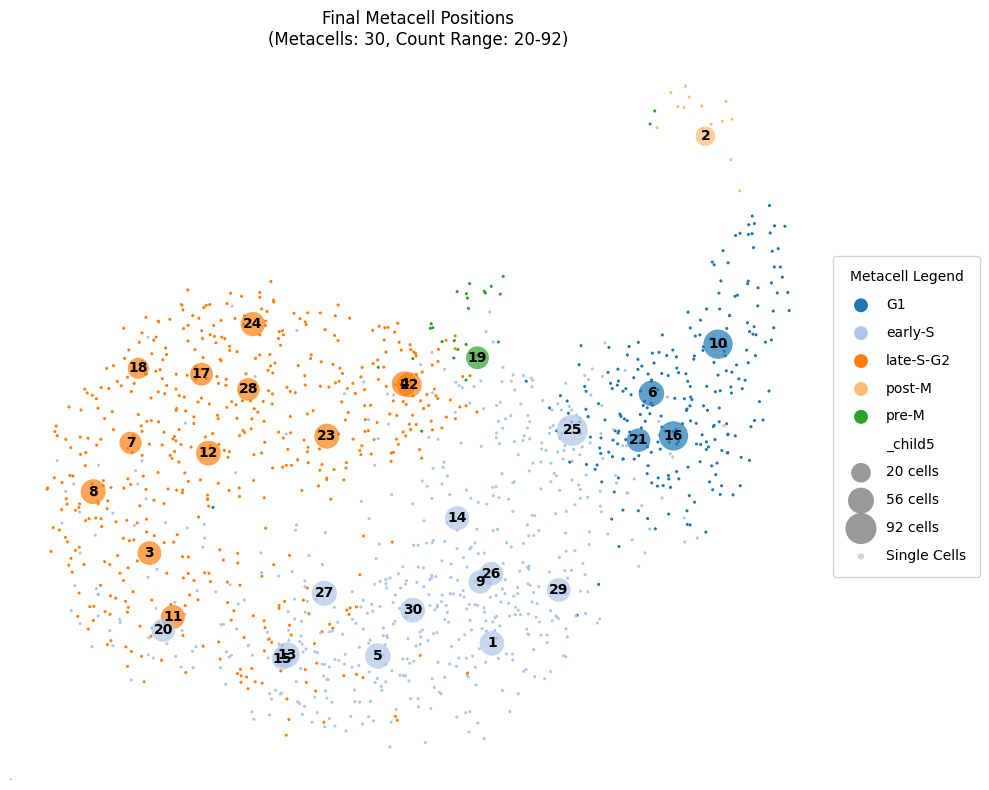

In [35]:
sk.pl.plot_metacells2(hdata, resolution=1000000, title="Final Metacell Positions",
             min_size=200, max_size=500, 
             show_idx=True, label_col='label', 
             cell_alpha=1, metacell_alpha=0.7)


In [36]:
# import numpy as np
# import scipy.sparse as sp
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from scipy.ndimage import gaussian_filter1d
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# # ================= 1. 配置与参数 =================
# resolution = 50000

# bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
# n_bins = len(bin_edges) - 1
# bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

# phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
# phase_colors = ['Red', 'Blue', 'green', 'purple', 'orange']
# metacell_ct = hdata.metacells.CellType.to_dict()
# metacell_mat_dict = hdata.metacell_data['mat'][str(resolution)]

# # ================= 2. 计算衰减 (加入 Dithering) =================
# metacell_decay = {}
# print(f"Total cells to process: {len(metacell_mat_dict)}")

# for cell_id, chrom_dict in metacell_mat_dict.items():
#     decay_counts = np.zeros(n_bins, dtype=np.float32)
    
#     for chrom, sparse_mat in chrom_dict.items():
#         try:
#             if sparse_mat.nnz == 0: 
#                 continue
            
#             upper_coo = sp.triu(sparse_mat, k=1).tocoo()
#             if upper_coo.nnz == 0: 
#                 continue
            
#             bin1 = upper_coo.row
#             bin2 = upper_coo.col
#             vals = upper_coo.data.astype(np.float32)
            
#             dists_bins = bin2 - bin1
#             jitter = np.random.uniform(-resolution/2, resolution/2, size=len(dists_bins))
#             dists = dists_bins * resolution + jitter
#             dists = np.maximum(dists, 1.0) 
            
#             bin_idx = np.searchsorted(bin_edges, dists) - 1
#             valid = (bin_idx >= 0) & (bin_idx < n_bins)
            
#             if valid.any():
#                 counts = np.bincount(bin_idx[valid], weights=vals[valid], minlength=n_bins)
#                 decay_counts += counts
                
#         except Exception as e:
#             pass
            
#     metacell_decay[cell_id] = decay_counts

# # ================= 3. 数据整理、截断与排序 =================
# all_valid_cells = [idx for idx in metacell_decay.keys() if idx in metacell_ct]

# temp_mat = np.array([metacell_decay[idx] for idx in all_valid_cells])
# temp_row_sums = temp_mat.sum(axis=1, keepdims=True)
# temp_row_sums[temp_row_sums == 0] = 1
# temp_norm_mat = temp_mat / temp_row_sums

# min_dist_cutoff = 2 ** 16.2
# valid_bins = bin_edges[:-1] >= min_dist_cutoff
# temp_trunc_mat = temp_norm_mat[:, valid_bins]

# n_cols = temp_trunc_mat.shape[1]
# col_indices = np.arange(n_cols)

# cell_com_scores = {}
# for i, idx in enumerate(all_valid_cells):
#     row_data = temp_trunc_mat[i]
#     row_sum = row_data.sum()
#     if row_sum > 0:
#         probs = row_data / row_sum
#         com = np.sum(probs * col_indices)
#     else:
#         com = 0
#     cell_com_scores[idx] = com

# sorted_indices = []
# for phase in phase_order:
#     cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]
#     cells_in_phase_sorted = sorted(cells_in_phase, key=lambda x: cell_com_scores[x])
#     if phase == 'G1' or phase == 'early-S' or phase == 'late-S-G2':

#             cells_in_phase_sorted = cells_in_phase_sorted[::-1]
#     print(cells_in_phase_sorted)
#     print(phase)
#     sorted_indices.extend(cells_in_phase_sorted)

# n_cells = len(sorted_indices)

# raw_mat = np.array([metacell_decay[idx] for idx in sorted_indices])
# row_sums = raw_mat.sum(axis=1, keepdims=True)
# row_sums[row_sums == 0] = 1
# norm_mat = raw_mat / row_sums

# n_valid_bins = valid_bins.sum()
# trunc_mat = norm_mat[:, valid_bins]

# decay_mat = gaussian_filter1d(trunc_mat, sigma=1.5, axis=1)

# # ================= 4. 绘图 =================
# fig = plt.figure(figsize=(20, 8))
# gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# # --- 4.1 主热图 ---
# ax_main = fig.add_subplot(gs[0])
# zlim = (0, 0.025)

# ax_main.grid(visible=False, axis='y')
# ax_main.grid(visible=False, axis='x')

# im = ax_main.imshow(
#     np.clip(decay_mat.T, zlim[0], zlim[1]),
#     aspect='auto',
#     cmap='RdYlBu_r', 
#     vmin=zlim[0],
#     vmax=zlim[1],
#     interpolation='nearest',
#     origin='lower' 
# )

# valid_bin_mids = bin_mids[valid_bins]
# tick_every = 4
# tick_pos = np.arange(0, n_valid_bins, tick_every)
# tick_labels = [f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
#                for v in valid_bin_mids[tick_pos]]

# ax_main.set_yticks(tick_pos)
# ax_main.set_yticklabels(tick_labels, fontsize=8)
# ax_main.set_xticks([])  
# ax_main.set_ylabel('Genomic distance')

# divider = make_axes_locatable(ax_main)
# ax_cb = divider.append_axes("right", size="1%", pad=0.05)
# plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# # --- 4.2 条件色条 (Phase Bar) ---
# ax_cond = fig.add_subplot(gs[1])
# cond_colors = np.zeros((1, n_cells, 3))

# phase_color_map = dict(zip(phase_order, phase_colors))
# for col, idx in enumerate(sorted_indices):
#     lb = metacell_ct[idx]
#     rgb = mcolors.to_rgb(phase_color_map[lb])
#     cond_colors[0, col] = rgb

# ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
# ax_cond.set_xticks([])
# ax_cond.set_yticks([0])
# ax_cond.set_yticklabels(['Phase'], fontsize=8)
# ax_cond.grid(False) 

# cum = 0
# for phase in phase_order:
#     cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
#     if cnt > 0:
#         ax_cond.text(cum + cnt/2 - cnt*0.5, 0, phase, ha='center', va='center',
#              fontsize=9, color='white', fontweight='bold')
#     cum += cnt

# # ax_cond 右侧加占位，与 ax_main 对齐
# divider_cond = make_axes_locatable(ax_cond)
# ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
# ax_cond_dummy.axis('off')

# # --- 4.3 排版 ---
# plt.suptitle('Single-cell Decay Heatmap (Grouped by phase, smoothed internally)', fontsize=14, y=0.95)
# plt.show()
# mc_sorted = sorted_indices        # 改这里
# mc_decay_mat = decay_mat          # 改这里
# mc_trunc = trunc_mat              # 改这里
# sorted_metacells = sorted_indices
# metacell_com = cell_com_scores
# mc_sorted = sorted_metacells   # 用sorted_metacells而不是sorted_indices
# mc_decay = decay_mat
# mc_ct = metacell_ct

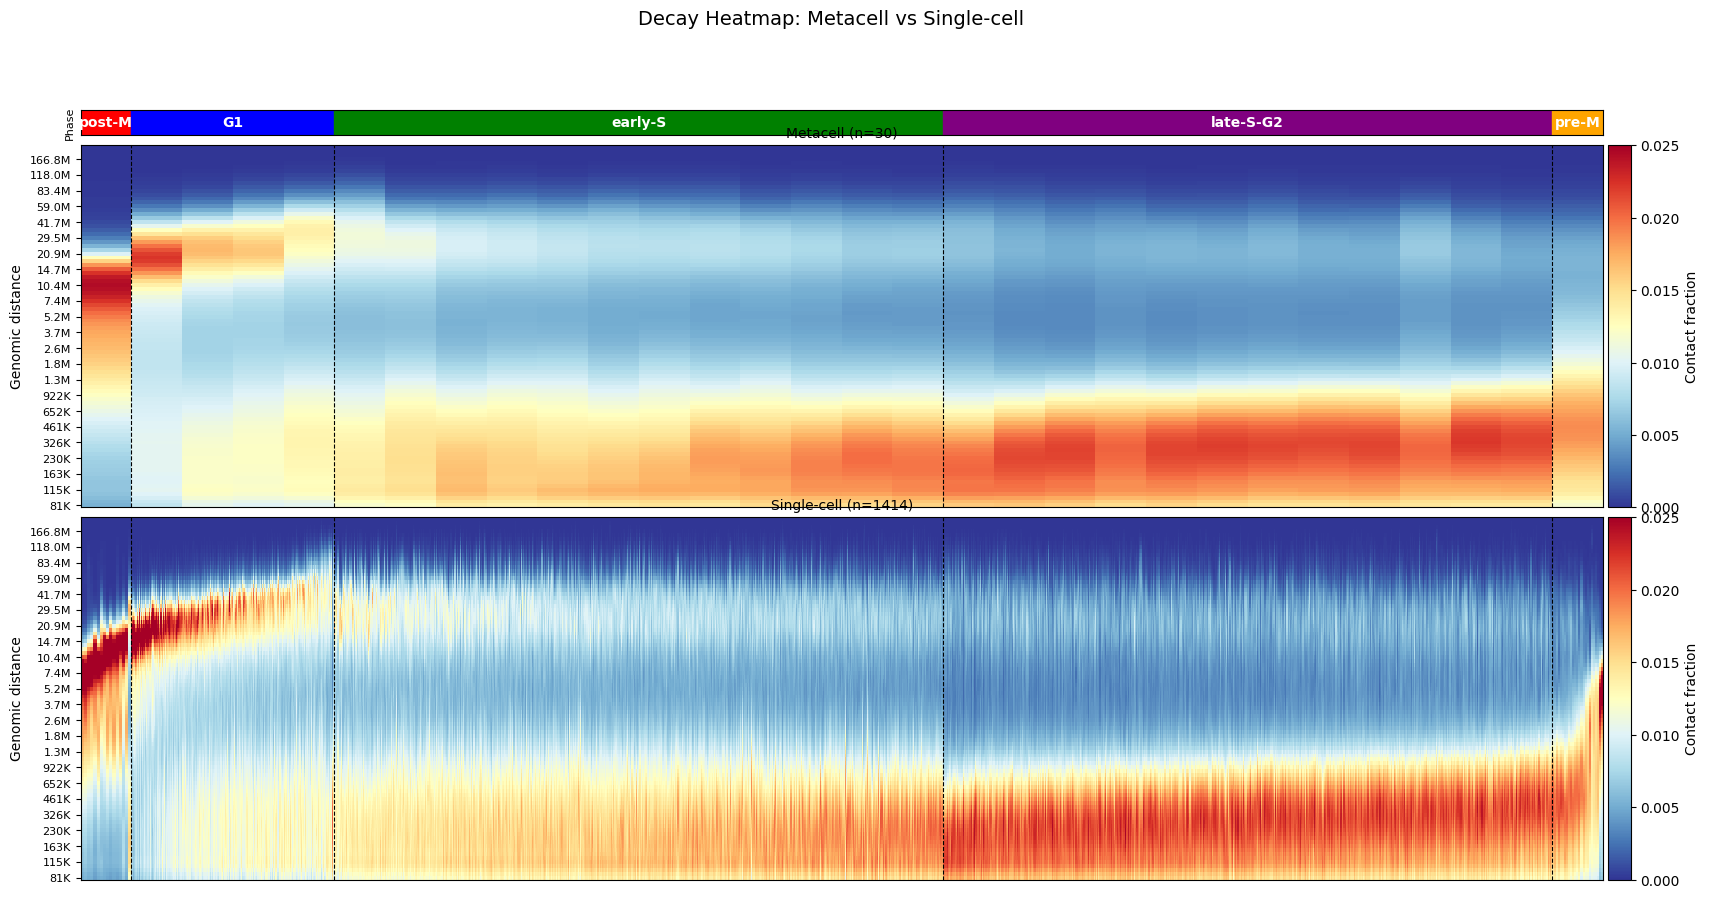

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter1d

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['Red', 'Blue', 'green', 'purple', 'orange']
phase_color_map = dict(zip(phase_order, phase_colors))

# ================= 数据准备 =================
# metacell（文档6变量）
mc_sorted = sorted_indices          # metacell排好序的id列表
mc_decay = decay_mat                # (n_mc, n_valid_bins)，已gaussian
mc_ct = metacell_ct                 # id -> phase

# 单细胞（文档5变量，需要重新命名避免冲突）
# 假设文档5的变量存为：sc_sorted_indices, sc_decay_mat, sc_trunc_mat
# 如果变量名有冲突请告诉我，我来调整

# phase在metacell中的count
mc_phase_cnt = {p: sum(1 for idx in mc_sorted if mc_ct[idx] == p) for p in phase_order}
# phase在单细胞中的count  
cell_obs_index = list(hdata.obs.index)
sc_phase_cnt = {p: sum(1 for i in sc_sorted_indices if cell_ct[cell_obs_index[i]] == p) for p in phase_order}

# 计算每个phase的归一化宽度（按metacell比例，两图共用）
total_mc = sum(mc_phase_cnt.values())
phase_widths = {p: mc_phase_cnt[p] / total_mc for p in phase_order}  # 归一化物理宽度

# 构建x坐标映射：把每个cell/metacell映射到统一的[0,1]物理空间
def make_extent_blocks(sorted_list, ct_dict, phase_order, phase_widths):
    """返回每列对应的物理x坐标"""
    x_coords = np.zeros(len(sorted_list) + 1)
    cum_phys = 0
    pos = 0
    for phase in phase_order:
        cells = [idx for idx in sorted_list if ct_dict[idx] == phase]
        n = len(cells)
        if n == 0:
            continue
        w = phase_widths[phase]
        for k in range(n):
            x_coords[pos + k] = cum_phys + k * w / n
        pos += n
        cum_phys += w
    x_coords[-1] = 1.0
    return x_coords

# metacell x坐标
mc_x = make_extent_blocks(mc_sorted, mc_ct, phase_order, phase_widths)

# 单细胞需要用整数index映射
def make_extent_blocks_sc(sorted_list, obs_index, ct_dict, phase_order, phase_widths):
    x_coords = np.zeros(len(sorted_list) + 1)
    cum_phys = 0
    pos = 0
    for phase in phase_order:
        cells = [i for i in sorted_list if ct_dict[obs_index[i]] == phase]
        n = len(cells)
        if n == 0:
            continue
        w = phase_widths[phase]
        for k in range(n):
            x_coords[pos + k] = cum_phys + k * w / n
        pos += n
        cum_phys += w
    x_coords[-1] = 1.0
    return x_coords

sc_x = make_extent_blocks_sc(sc_sorted_indices, cell_obs_index, cell_ct, phase_order, phase_widths)

# ================= 绘图 =================
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[0.5, 7, 7], hspace=0.04)

valid_bin_mids = bin_mids[valid_bins]
tick_every = 4
tick_pos = np.arange(0, valid_bins.sum(), tick_every)
tick_labels = [f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K' for v in valid_bin_mids[tick_pos]]

# --- Phase bar（共用，最上面）---
ax_phase = fig.add_subplot(gs[0])
cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if w > 0:
        ax_phase.axvspan(cum_phys, cum_phys + w, color=phase_color_map[phase], alpha=1)
        ax_phase.text(cum_phys + w/2, 0.5, phase, ha='center', va='center',
                      fontsize=10, color='white', fontweight='bold',
                      transform=ax_phase.get_xaxis_transform())
        cum_phys += w
ax_phase.set_xlim(0, 1)
ax_phase.set_xticks([])
ax_phase.set_yticks([])
ax_phase.set_ylabel('Phase', fontsize=8)

divider_phase = make_axes_locatable(ax_phase)
ax_phase_dummy = divider_phase.append_axes("right", size="1.5%", pad=0.05)
ax_phase_dummy.axis('off')

# --- Metacell 热图 ---
ax_mc = fig.add_subplot(gs[1])
zlim = (0, 0.025)

# 用pcolormesh支持非等宽列
X_mc, Y_mc = np.meshgrid(mc_x, np.arange(mc_decay.shape[1] + 1) - 0.5)
im_mc = ax_mc.pcolormesh(X_mc, Y_mc,
                          np.clip(mc_decay.T, zlim[0], zlim[1]),
                          cmap='RdYlBu_r', vmin=zlim[0], vmax=zlim[1],
                          shading='flat')

ax_mc.set_yticks(tick_pos)
ax_mc.set_yticklabels(tick_labels, fontsize=8)
ax_mc.set_xticks([])
ax_mc.set_ylabel('Genomic distance')
ax_mc.set_xlim(0, 1)
ax_mc.set_title(f'Metacell (n={len(mc_sorted)})', fontsize=10)

divider_mc = make_axes_locatable(ax_mc)
ax_cb_mc = divider_mc.append_axes("right", size="1.5%", pad=0.05)
plt.colorbar(im_mc, cax=ax_cb_mc, label='Contact fraction')

# phase边界线
cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if cum_phys > 0:
        ax_mc.axvline(cum_phys, color='black', lw=0.8, linestyle='--')
    cum_phys += w

# --- 单细胞热图 ---
ax_sc = fig.add_subplot(gs[2])
sc_decay_plot = gaussian_filter1d(sc_trunc_mat[sc_sorted_indices], sigma=1.5, axis=1)

X_sc, Y_sc = np.meshgrid(sc_x, np.arange(sc_decay_plot.shape[1] + 1) - 0.5)
im_sc = ax_sc.pcolormesh(X_sc, Y_sc,
                          np.clip(sc_decay_plot.T, zlim[0], zlim[1]),
                          cmap='RdYlBu_r', vmin=zlim[0], vmax=zlim[1],
                          shading='flat')

ax_sc.set_yticks(tick_pos)
ax_sc.set_yticklabels(tick_labels, fontsize=8)
ax_sc.set_xticks([])
ax_sc.set_ylabel('Genomic distance')
ax_sc.set_xlim(0, 1)
ax_sc.set_title(f'Single-cell (n={len(sc_sorted_indices)})', fontsize=10)

divider_sc = make_axes_locatable(ax_sc)
ax_cb_sc = divider_sc.append_axes("right", size="1.5%", pad=0.05)
plt.colorbar(im_sc, cax=ax_cb_sc, label='Contact fraction')

cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if cum_phys > 0:
        ax_sc.axvline(cum_phys, color='black', lw=0.8, linestyle='--')
    cum_phys += w

plt.suptitle('Decay Heatmap: Metacell vs Single-cell', fontsize=14, y=0.98)
plt.savefig('decay_heatmap_combined.pdf', bbox_inches='tight')
plt.show()

In [38]:
# # 构建 metacell -> pseudotime rank 的映射
# import seaborn as sns
# mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}

# def plot_metacells_pseudotime(hdata, sorted_metacells, resolution=None, title="Metacell Pseudotime Order",
#                                min_size=50, max_size=500, label_col='label',
#                                cell_alpha=0.3, metacell_alpha=0.8, save_path=None, dpi=300):
#     if resolution is None:
#         raise ValueError("请提供 resolution 参数")

#     import pandas as pd
#     labels = hdata.obs['metacell']
#     umap_coords = hdata.views_umap[resolution]
#     present_indices = np.unique(labels)

#     cell_labels = hdata.obs[label_col].values
#     if 'eval_df_cache' in hdata.uns:
#         unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
#     else:
#         unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
#     palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
#     color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

#     metacell_coords, metacell_counts, metacell_dominant_labels = [], [], []
#     for k in present_indices:
#         indices = np.where(labels == k)[0]
#         metacell_coords.append(np.mean(umap_coords[indices], axis=0))
#         metacell_counts.append(len(indices))
#         dom_label = pd.Series(cell_labels[indices]).value_counts().index[0]
#         metacell_dominant_labels.append(dom_label)

#     metacell_coords = np.array(metacell_coords)
#     metacell_counts = np.array(metacell_counts)

#     if metacell_counts.max() > metacell_counts.min():
#         norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
#         plot_sizes = min_size + norm_sizes * (max_size - min_size)
#     else:
#         plot_sizes = np.full(len(metacell_counts), (min_size + max_size) / 2)

#     mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
#     mc_colors = [color_map.get(lbl, 'blue') for lbl in metacell_dominant_labels]
#     cell_colors_list = [color_map.get(lbl, 'lightgrey') for lbl in cell_labels]

#     plt.figure(figsize=(10, 8))
#     plt.scatter(umap_coords[:, 0], umap_coords[:, 1],
#                 c=cell_colors_list, s=5, alpha=cell_alpha, rasterized=True, edgecolors='none', linewidth=0)
#     plt.scatter(metacell_coords[:, 0], metacell_coords[:, 1],
#                 c=mc_colors, s=plot_sizes, edgecolors='none', linewidths=0, alpha=metacell_alpha, zorder=10)

#     # 标注pseudotime rank
#     for i, k in enumerate(present_indices):
#         rank = mc_pseudotime_rank.get(k, '?')
#         plt.text(metacell_coords[i, 0], metacell_coords[i, 1], str(rank),
#                  fontsize=9, ha='center', va='center', color='white', fontweight='bold', zorder=20)

#     handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
#                for lbl in unified_hue_order]
#     handles.append(plt.scatter([], [], c='white', s=0, label=''))
#     min_c, max_c = metacell_counts.min(), metacell_counts.max()
#     mid_c = int((min_c + max_c) / 2)
#     for s, l in zip([min_size, (min_size+max_size)/2, max_size],
#                     [f'{min_c} cells', f'{mid_c} cells', f'{max_c} cells']):
#         handles.append(plt.scatter([], [], c='gray', alpha=0.8, s=s, edgecolors='none', label=l))
#     handles.append(plt.scatter([], [], c='lightgrey', s=20, edgecolors='none', label='Single Cells'))

#     plt.legend(handles=handles, title="Metacell Legend", loc='center left',
#                bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)
#     plt.title(f"{title}\n(Metacells: {len(metacell_coords)}, pseudotime rank labeled)")
#     plt.axis('off')
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
#     plt.show()

# plot_metacells_pseudotime(hdata, sorted_metacells, resolution=1000000)

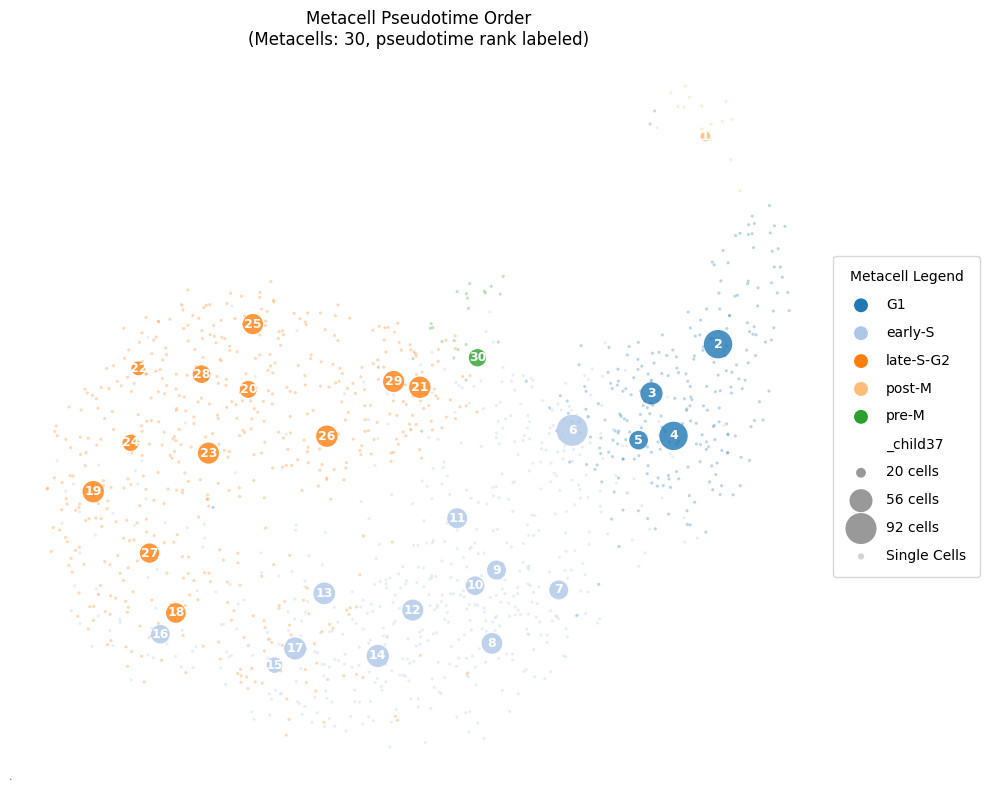

In [39]:
# 构建 metacell -> pseudotime rank 的映射
import seaborn as sns
mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
def plot_metacells_pseudotime(hdata, sorted_metacells, resolution=None, title="Metacell Pseudotime Order",
                               min_size=50, max_size=500, label_col='label',
                               cell_alpha=0.3, metacell_alpha=0.8, save_path=None, dpi=300,
                               recompute_umap=False, umap_neighbors=10, umap_min_dist=1,
                               repulse=True, repulse_radius=0.5, repulse_iters=50):
    if resolution is None:
        raise ValueError("请提供 resolution 参数")

    import pandas as pd
    import umap
    labels = hdata.obs['metacell']

    if recompute_umap:
        print('recompute umap')
        pca_coords = hdata.views_pca[resolution]
        reducer = umap.UMAP(n_neighbors=umap_neighbors, min_dist=umap_min_dist, random_state=42)
        umap_coords = reducer.fit_transform(pca_coords)
    else:
        umap_coords = hdata.views_umap[resolution]

    present_indices = np.unique(labels)
    cell_labels = hdata.obs[label_col].values
    if 'eval_df_cache' in hdata.uns:
        unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
    else:
        unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
    palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
    color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

    metacell_coords, metacell_counts, metacell_dominant_labels = [], [], []
    for k in present_indices:
        indices = np.where(labels == k)[0]
        metacell_coords.append(np.mean(umap_coords[indices], axis=0))
        metacell_counts.append(len(indices))
        dom_label = pd.Series(cell_labels[indices]).value_counts().index[0]
        metacell_dominant_labels.append(dom_label)

    metacell_coords = np.array(metacell_coords)
    metacell_counts = np.array(metacell_counts)

    # repulsion：将过近的 metacell 点推开
    if repulse:
        for _ in range(repulse_iters):
            for i in range(len(metacell_coords)):
                for j in range(i+1, len(metacell_coords)):
                    diff = metacell_coords[i] - metacell_coords[j]
                    dist = np.linalg.norm(diff)
                    if dist < repulse_radius and dist > 1e-6:
                        push = (repulse_radius - dist) / 2 * diff / dist
                        metacell_coords[i] += push
                        metacell_coords[j] -= push

    if metacell_counts.max() > metacell_counts.min():
        norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
        plot_sizes = min_size + norm_sizes * (max_size - min_size)
    else:
        plot_sizes = np.full(len(metacell_counts), (min_size + max_size) / 2)

    mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
    mc_colors = [color_map.get(lbl, 'blue') for lbl in metacell_dominant_labels]
    cell_colors_list = [color_map.get(lbl, 'lightgrey') for lbl in cell_labels]

    plt.figure(figsize=(10, 8))
    plt.scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=cell_colors_list, s=5, alpha=cell_alpha, rasterized=True, edgecolors='none', linewidth=0)
    plt.scatter(metacell_coords[:, 0], metacell_coords[:, 1],
                c=mc_colors, s=plot_sizes, edgecolors='none', linewidths=0, alpha=metacell_alpha, zorder=10)

    for i, k in enumerate(present_indices):
        rank = mc_pseudotime_rank.get(k, '?')
        plt.text(metacell_coords[i, 0], metacell_coords[i, 1], str(rank),
                 fontsize=9, ha='center', va='center', color='white', fontweight='bold', zorder=20)

    handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
               for lbl in unified_hue_order]
    handles.append(plt.scatter([], [], c='white', s=0, label=''))
    min_c, max_c = metacell_counts.min(), metacell_counts.max()
    mid_c = int((min_c + max_c) / 2)
    for s, l in zip([min_size, (min_size+max_size)/2, max_size],
                    [f'{min_c} cells', f'{mid_c} cells', f'{max_c} cells']):
        handles.append(plt.scatter([], [], c='gray', alpha=0.8, s=s, edgecolors='none', label=l))
    handles.append(plt.scatter([], [], c='lightgrey', s=20, edgecolors='none', label='Single Cells'))

    plt.legend(handles=handles, title="Metacell Legend", loc='center left',
               bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)
    plt.title(f"{title}\n(Metacells: {len(metacell_coords)}, pseudotime rank labeled)")
    plt.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
plot_metacells_pseudotime(hdata, sorted_metacells, resolution=1000000, save_path='./time_umap.pdf')

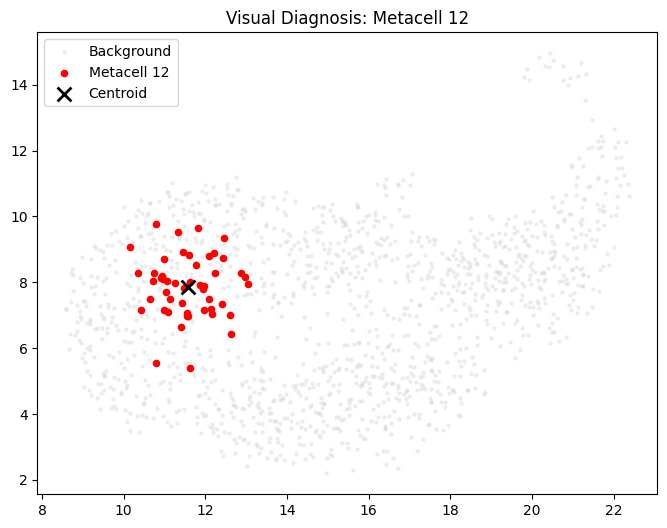

In [40]:
sk.pl.plot_specific_metacell(hdata, metacell_id=12, resolution=1000000)


In [41]:
# import umap
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ================= 用decay profile重新跑UMAP =================
# decay_for_umap = temp_trunc_mat[[mc - 1 for mc in sorted_metacells]]

# reducer = umap.UMAP(n_neighbors=5, min_dist=1, metric='cosine', random_state=42)
# mc_umap_coords = reducer.fit_transform(decay_for_umap)

# # ================= 绘图 =================
# cell_labels = hdata.obs['label'].values
# if 'eval_df_cache' in hdata.uns:
#     unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
# else:
#     unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
# palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
# color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

# mc_colors = [color_map.get(metacell_ct[mc], 'gray') for mc in sorted_metacells]
# metacell_counts = np.array([sum(hdata.obs['metacell'] == mc) for mc in sorted_metacells])

# if metacell_counts.max() > metacell_counts.min():
#     norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
#     plot_sizes = 50 + norm_sizes * 450
# else:
#     plot_sizes = np.full(len(metacell_counts), 250)

# fig, ax = plt.subplots(figsize=(10, 8))

# # 画连线
# for i in range(len(sorted_metacells) - 1):
#     x0, y0 = mc_umap_coords[i]
#     x1, y1 = mc_umap_coords[i+1]
#     ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
#                 arrowprops=dict(arrowstyle='->', color='gray', lw=1.0, alpha=0.6))

# # 散点
# ax.scatter(mc_umap_coords[:, 0], mc_umap_coords[:, 1],
#            c=mc_colors, s=plot_sizes, edgecolors='white', linewidths=0.5,
#            alpha=0.9, zorder=10)

# # 标注pseudotime rank
# for i, mc in enumerate(sorted_metacells):
#     ax.text(mc_umap_coords[i, 0], mc_umap_coords[i, 1], str(i+1),
#             fontsize=8, ha='center', va='center', color='white', fontweight='bold', zorder=20)

# handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
#            for lbl in unified_hue_order]
# ax.legend(handles=handles, title='Phase', loc='center left',
#           bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)

# ax.set_title('Metacell UMAP (decay profile, pseudotime labeled)')
# ax.axis('off')
# plt.tight_layout()
# plt.savefig('metacell_decay_umap.pdf', bbox_inches='tight')
# plt.show()

In [42]:
hdata

HData object with 1414 cells and 30 metacells
    resolutions: [np.int64(50000), np.int64(100000), np.int64(500000), np.int64(1000000), np.int64(2000000)]
    obs: ['depth', 'label', 'metacell']
    views_pca: [1000000, 50000, 500000]
    views_umap: [1000000, 50000, 500000]
    views_embedding: [1000000, 50000, 500000]
    views_mat: [1000000, 50000, 500000]
    views_is: []
    uns keys: ['accuracy', 'avg_size_cache', 'cs_res_df', 'eval_df_cache', 'global_score', 'hwis', 'mean_compactness', 'mean_separation', 'metrics', 'purity_df', 'recommended_k', 'thre_cache', 'wcos']
    metacells: ['CellType', 'CellType_purity', 'cell_num', 'w_min', 'w_max', 'P_adj', 'EP_v2', 'total_depth', 'cell_count', 'mean_depth', 'dominant_label']
    metacell_data keys: ['cool', 'mat', 'mcool', 'pairs']
    model: MultiViewSEACells (trained: True)

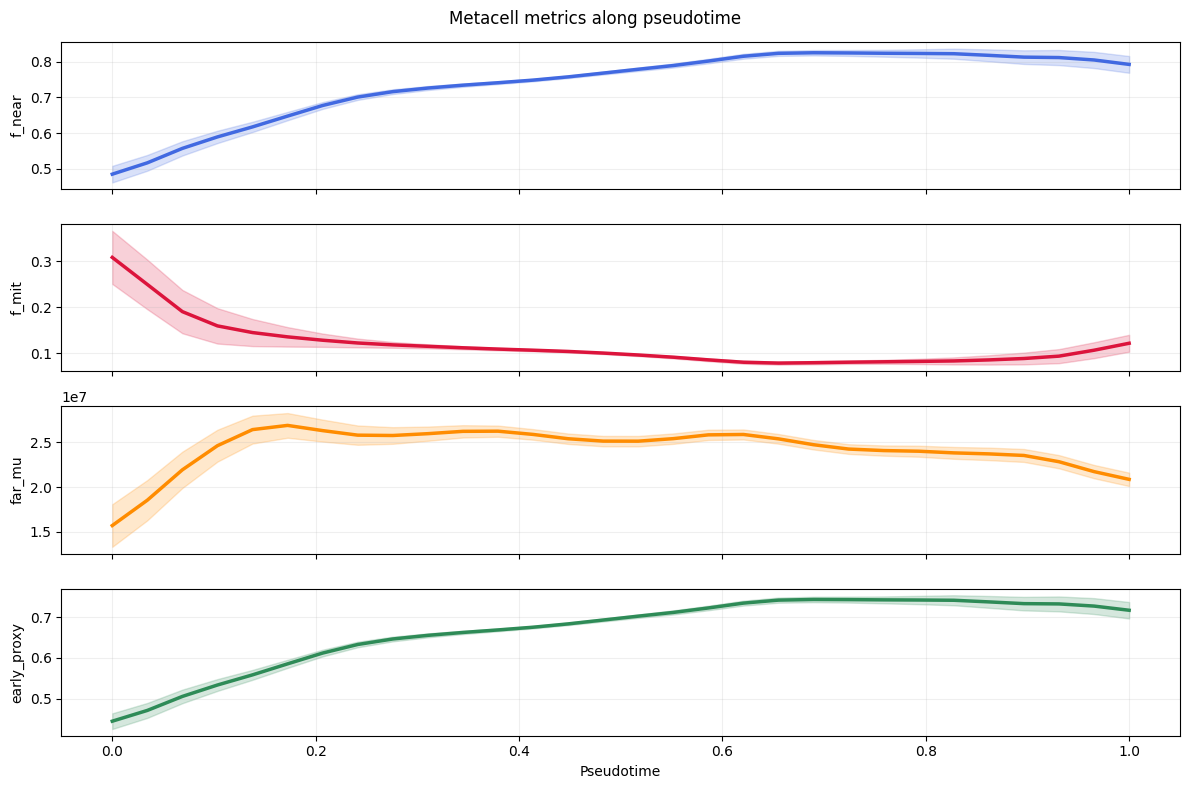

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 以当前排序作为拟时序
pseudotime = np.linspace(0, 1, len(sorted_indices))

pt_metrics = {
    "f_near": np.array([cell_metrics[idx]["f_near"] for idx in sorted_indices], dtype=float),
    "f_mit": np.array([cell_metrics[idx]["f_mit"] for idx in sorted_indices], dtype=float),
    "far_mu": np.array([cell_metrics[idx]["far_mu"] for idx in sorted_indices], dtype=float),
    "early_proxy": np.array([cell_metrics[idx]["early_f"] for idx in sorted_indices], dtype=float),
}

def smooth_with_band(vals, sigma_mean=1.5, sigma_sd=3):
    mean_s = gaussian_filter1d(vals, sigma=sigma_mean)
    resid2 = (vals - mean_s) ** 2
    sd_s = np.sqrt(gaussian_filter1d(resid2, sigma=sigma_sd))
    return mean_s, sd_s

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

metric_colors = {
    "f_near": "royalblue",
    "f_mit": "crimson",
    "far_mu": "darkorange",
    "early_proxy": "seagreen",
}

for ax, (name, vals) in zip(axes, pt_metrics.items()):
    mean_s, sd_s = smooth_with_band(vals, sigma_mean=1.2, sigma_sd=2.5)
    color = metric_colors[name]

    ax.fill_between(
        pseudotime,
        mean_s - sd_s,
        mean_s + sd_s,
        color=color,
        alpha=0.2
    )
    ax.plot(pseudotime, mean_s, color=color, linewidth=2.5)
    ax.set_ylabel(name)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Pseudotime")
plt.suptitle("Metacell metrics along pseudotime", y=0.98)
plt.tight_layout()
plt.show()


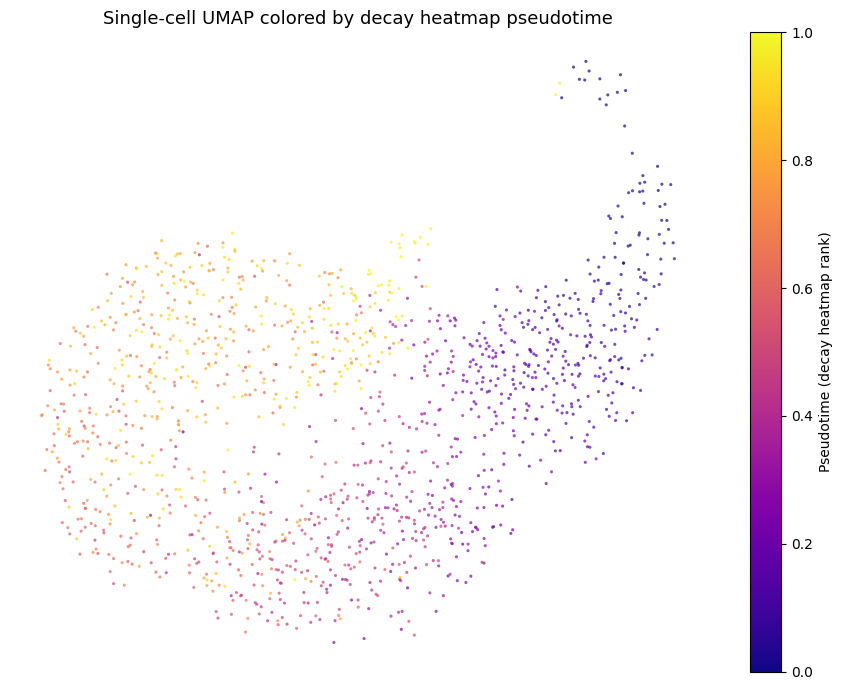

In [44]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ================= 1. 构建单细胞拟时序值 =================
# sc_sorted_indices 是按 decay heatmap 排好序的细胞索引列表
# 给每个细胞赋拟时序值 [0, 1]
n_sc = len(sc_sorted_indices)
pseudotime_values = np.linspace(0, 1, n_sc)

# cell_index -> pseudotime
cell_pseudotime = np.full(len(cell_names), np.nan)
for rank, cell_idx in enumerate(sc_sorted_indices):
    cell_pseudotime[cell_idx] = pseudotime_values[rank]

# ================= 2. 获取 UMAP 坐标 =================
umap_coords = hdata.views_umap[1000000]   # shape: (n_cells, 2)

# ================= 3. 绘图 =================
fig, ax = plt.subplots(figsize=(9, 7))

cmap = plt.get_cmap('plasma')
norm = Normalize(vmin=0, vmax=1)

# 先画没有拟时序值的细胞（灰色背景）
no_pt_mask = np.isnan(cell_pseudotime)
if no_pt_mask.any():
    ax.scatter(
        umap_coords[no_pt_mask, 0], umap_coords[no_pt_mask, 1],
        s=3, color='lightgrey', alpha=0.3, edgecolors='none', rasterized=True
    )

# 再画有拟时序值的细胞，按拟时序着色
pt_mask = ~no_pt_mask
sc = ax.scatter(
    umap_coords[pt_mask, 0], umap_coords[pt_mask, 1],
    c=cell_pseudotime[pt_mask],
    cmap=cmap, norm=norm,
    s=5, alpha=0.7, edgecolors='none', rasterized=True
)

plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Pseudotime (decay heatmap rank)')
ax.set_title('Single-cell UMAP colored by decay heatmap pseudotime', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('umap_pseudotime.pdf', bbox_inches='tight')
plt.show()


Fitting UMAP on single-cell decay profiles ...
UMAP done.


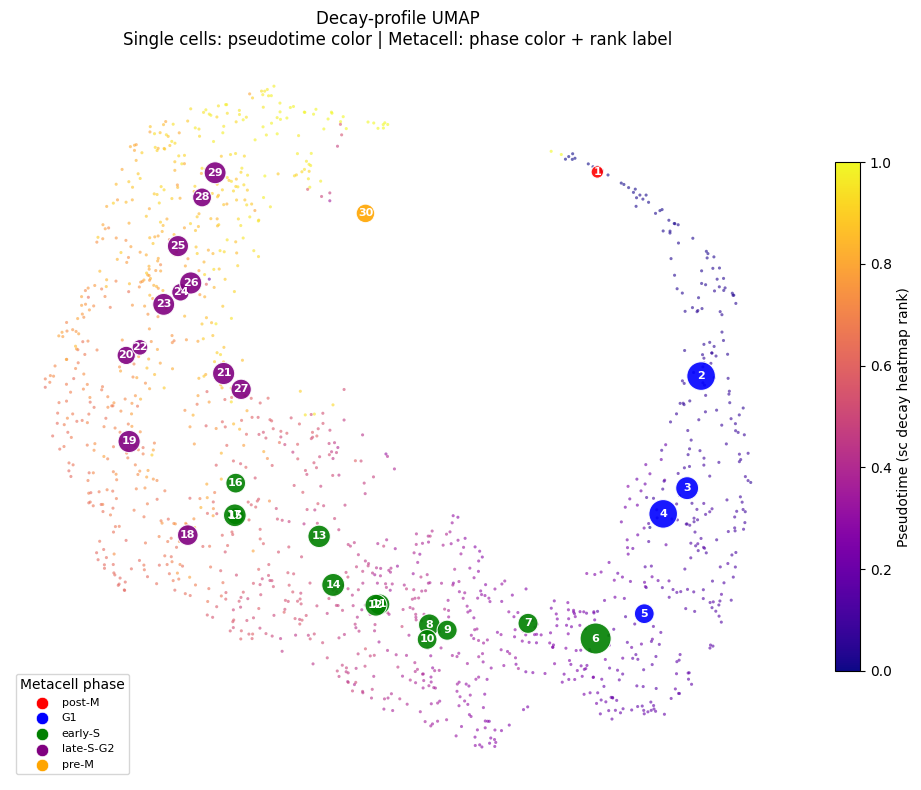

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import umap as umap_lib
import seaborn as sns

# ================= 1. 用单细胞 decay 向量拟合 UMAP =================
print("Fitting UMAP on single-cell decay profiles ...")
reducer = umap_lib.UMAP(n_neighbors=15, min_dist=0.3, metric='cosine', random_state=42, n_jobs=1)
sc_umap_coords = reducer.fit_transform(sc_trunc_mat)   # (n_cells, 2)
print("UMAP done.")

# ================= 2. metacell UMAP 坐标 = 其包含单细胞坐标的均值 =================
# 避免调用 reducer.transform()，改用聚合方式，更稳定
mc_assign = hdata.obs['metacell'].values   # 每个单细胞对应的 metacell id

mc_umap_coords = np.zeros((len(sorted_metacells), 2))
for i, mc_id in enumerate(sorted_metacells):
    member_mask = mc_assign == mc_id
    if member_mask.any():
        mc_umap_coords[i] = sc_umap_coords[member_mask].mean(axis=0)

# ================= 3. 单细胞拟时序着色 =================
n_sc_total = sc_trunc_mat.shape[0]
cell_pseudotime_decay = np.full(n_sc_total, np.nan)
for rank_i, cell_idx in enumerate(sc_sorted_indices):
    cell_pseudotime_decay[cell_idx] = rank_i / (len(sc_sorted_indices) - 1)

# ================= 4. metacell 尺寸（按包含细胞数） =================
mc_sizes_map = {mc_id: int((mc_assign == mc_id).sum()) for mc_id in sorted_metacells}
mc_sizes_arr = np.array([mc_sizes_map[mc_id] for mc_id in sorted_metacells], dtype=float)
if mc_sizes_arr.max() > mc_sizes_arr.min():
    norm_sz = (mc_sizes_arr - mc_sizes_arr.min()) / (mc_sizes_arr.max() - mc_sizes_arr.min())
    mc_plot_sizes = 80 + norm_sz * 420
else:
    mc_plot_sizes = np.full(len(sorted_metacells), 200.0)

# ================= 5. metacell 分期颜色 =================
phase_color_list = ['red', 'blue', 'green', 'purple', 'orange']
phase_order_local = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_color_map_local = dict(zip(phase_order_local, phase_color_list))
mc_face_colors = [phase_color_map_local.get(mc_ct.get(mc_id, ''), 'gray') for mc_id in sorted_metacells]

# ================= 6. 绘图 =================
cmap_pt = plt.get_cmap('plasma')
norm_pt = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(10, 8))

# 6.1 单细胞散点（按拟时序着色）
no_pt = np.isnan(cell_pseudotime_decay)
if no_pt.any():
    ax.scatter(sc_umap_coords[no_pt, 0], sc_umap_coords[no_pt, 1],
               s=3, color='lightgrey', alpha=0.25, edgecolors='none', rasterized=True)

has_pt = ~no_pt
ax.scatter(sc_umap_coords[has_pt, 0], sc_umap_coords[has_pt, 1],
           c=cell_pseudotime_decay[has_pt],
           cmap=cmap_pt, norm=norm_pt,
           s=5, alpha=0.6, edgecolors='none', rasterized=True)

# 6.2 metacell 散点（分期颜色，边框白色）
ax.scatter(mc_umap_coords[:, 0], mc_umap_coords[:, 1],
           c=mc_face_colors, s=mc_plot_sizes,
           edgecolors='white', linewidths=0.8, alpha=0.9, zorder=10)

# 6.3 metacell rank 标注（decay heatmap 排名，从 1 开始）
for i, mc_id in enumerate(sorted_metacells):
    ax.text(mc_umap_coords[i, 0], mc_umap_coords[i, 1], str(i + 1),
            fontsize=8, ha='center', va='center',
            color='white', fontweight='bold', zorder=20)

# 6.4 colorbar（拟时序）
plt.colorbar(ScalarMappable(norm=norm_pt, cmap=cmap_pt), ax=ax,
             label='Pseudotime (sc decay heatmap rank)', shrink=0.7)

# 6.5 phase 图例
legend_handles = [
    plt.scatter([], [], c=[phase_color_map_local[p]], s=80, edgecolors='white',
                linewidths=0.5, label=p)
    for p in phase_order_local
]
ax.legend(handles=legend_handles, title='Metacell phase',
          loc='lower left', framealpha=0.8, fontsize=8)

ax.set_title('Decay-profile UMAP\nSingle cells: pseudotime color | Metacell: phase color + rank label',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('decay_umap_pseudotime_mc_rank.pdf', bbox_inches='tight')
plt.show()


In [46]:
import pandas as pd

# ================= 诊断：查看每个 metacell 的排序指标 =================
rank_target = 27   # 修改这里检查不同的 rank

diag_rows = []
for rank_i, mc_id in enumerate(sorted_metacells):
    phase = mc_ct.get(mc_id, '?')
    m = metacell_sort_metrics[mc_id]
    diag_rows.append({
        'rank': rank_i + 1,
        'mc_id': mc_id,
        'phase': phase,
        'f_near': m['f_near'],
        'f_mit': m['f_mit'],
        'far_mu': m['far_mu'],
        'early_f': m['early_f'],
        'f_far': m['f_far'],
    })

diag_df = pd.DataFrame(diag_rows)

# 打印完整表格
print("=== 所有 metacell 排序指标 ===")
print(diag_df.to_string(index=False, float_format='%.4f'))

# 打印目标 rank 附近的情况
print(f"\n=== rank {rank_target} 附近 (±3) ===")
mask = (diag_df['rank'] >= rank_target - 3) & (diag_df['rank'] <= rank_target + 3)
print(diag_df[mask].to_string(index=False, float_format='%.4f'))

# 打印每个 phase 的排序 key 值，方便对比
print("\n=== 各 phase 内排序 key ===")
for phase in ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']:
    sub = diag_df[diag_df['phase'] == phase].copy()
    if phase == 'post-M':
        sub['sort_key'] = -sub['f_mit']   # 降序
    elif phase == 'G1':
        sub['sort_key'] = sub['f_near'] + sub['far_mu']
    elif phase == 'early-S':
        sub['sort_key'] = sub['f_near'] + sub['early_f']
    elif phase == 'late-S-G2':
        sub['sort_key'] = -(sub['f_near'] - sub['early_f'])  # 降序后的等价升序key
    elif phase == 'pre-M':
        sub['sort_key'] = sub['f_mit']
    print(f"\n{phase}:")
    print(sub[['rank','mc_id','sort_key','f_near','f_mit','far_mu','early_f']].to_string(index=False, float_format='%.4f'))


=== 所有 metacell 排序指标 ===
 rank  mc_id     phase  f_near  f_mit        far_mu  early_f  f_far
    1      2    post-M  0.4502 0.3989 11804057.8533   0.4177 0.3943
    2     10        G1  0.5100 0.2006 20060324.4487   0.4638 0.4109
    3      6        G1  0.5856 0.1612 22625849.9750   0.5299 0.3500
    4     16        G1  0.5831 0.1564 24537135.0708   0.5281 0.3514
    5     21        G1  0.6114 0.1445 27637659.2501   0.5534 0.3258
    6     25   early-S  0.6511 0.1308 28964679.1681   0.5881 0.2917
    7     29   early-S  0.6784 0.1335 24845343.5924   0.6131 0.2624
    8      1   early-S  0.7155 0.1163 25489056.5188   0.6454 0.2325
    9     26   early-S  0.7159 0.1187 26040665.9314   0.6461 0.2292
   10      9   early-S  0.7267 0.1182 25272829.0470   0.6556 0.2183
   11     14   early-S  0.7379 0.1087 26889964.0983   0.6650 0.2123
   12     30   early-S  0.7396 0.1114 26341585.6792   0.6670 0.2072
   13     27   early-S  0.7470 0.1052 26452060.4800   0.6737 0.2030
   14      5   early-S 